In [ ]:
# Repair Cell: Run this, then RESTART SESSION
!pip install -U huggingface_hub transformers accelerate --quiet
print("✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.")

In [1]:
#--------------------------------------------------------------------------------------------------------
# MODULE 0: Environment Update
#--------------------------------------------------------------------------------------------------------

!pip install -U transformers datasets accelerate

In [2]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1: Dependencies & Environment Setup
#--------------------------------------------------------------------------------------------------------

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Scikit-learn for evaluation and splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Hugging Face Datasets
from datasets import load_dataset

# Transformers and Optimization
# FIX: AdamW is imported from torch.optim to avoid the Transformers ImportError
from torch.optim import AdamW 
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup

# Kaggle-specific secrets for gated datasets
from kaggle_secrets import UserSecretsClient

# 1. Device Configuration
# This ensures your model runs on the Kaggle GPU (T4 or P100)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Project environment ready.")
print(f"✅ Running on device: {device}")

# 2. Hugging Face Authentication
# Requires a Kaggle Secret named 'HF_TOKEN' containing your Hugging Face Read Token
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    print("✅ Hugging Face token retrieved from Secrets.")
except Exception as e:
    hf_token = None
    print("⚠️ Warning: 'HF_TOKEN' not found in Kaggle Secrets.")
    print("   Note: You must add your token to 'Add-ons -> Secrets' to access the SWMH dataset.")

✅ Project environment ready.
✅ Running on device: cuda
✅ Hugging Face token retrieved from Secrets.


In [3]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1.5: Verification Script
#--------------------------------------------------------------------------------------------------------

from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    token = user_secrets.get_secret("HF_TOKEN")
    
    print("Testing connection to gated dataset...")
    # Loading just a tiny sliver to verify access
    test_load = load_dataset("AIMH/SWMH", token=token, split='train', streaming=True)
    print("🚀 Success! Dataset is reachable and token is valid.")
    
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Ensure you have accepted the terms at: https://huggingface.co/datasets/AIMH/SWMH")

Testing connection to gated dataset...
🚀 Success! Dataset is reachable and token is valid.


In [4]:
#--------------------------------------------------------------------------------------------------------
# MODULE 2: Hyperparameters & Configuration
#--------------------------------------------------------------------------------------------------------

class Config:
    MODEL_NAME = 'bert-base-uncased'
    MAX_LEN = 256  # Increased for Reddit context
    BATCH_SIZE = 16
    EPOCHS = 4
    LEARNING_RATE_BERT = 2e-5
    LEARNING_RATE_WEIGHTS = 1e-3 # Higher LR for the new learnable layer weights
    RANDOM_SEED = 42
    
config = Config()
np.random.seed(config.RANDOM_SEED)
torch.manual_seed(config.RANDOM_SEED)

In [15]:
#--------------------------------------------------------------------------------------------------------
# MODULE 3: Data Pipeline (Merging & Alignment)
#--------------------------------------------------------------------------------------------------------

def load_and_preprocess_data():
    print("📊 Loading Kaggle Unbalanced Dataset...")
    base_path = "/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/"
    # Using the unbalanced set as the total pool
    df_total = pd.read_csv(f"{base_path}mental_heath_unbanlanced.csv")[['text', 'status']]

    label_map = {
        'Normal': 0, 'Depression': 1, 'Anxiety': 2, 'Suicidal': 3
    }
    df_total['label'] = df_total['status'].map(label_map)
    df_total = df_total.dropna(subset=['label']).reset_index(drop=True)

    # NEW STRATEGY: Create a perfectly balanced test set from the total pool
    # We take 250 samples from each class to ensure a fair 'Final Exam'
    test_samples_per_class = 250
    final_test_df = df_total.groupby('label').apply(lambda x: x.sample(test_samples_per_class, random_state=42)).reset_index(drop=True)
    
    # The training pool is everything EXCEPT those test samples
    train_val_df = df_total[~df_total.index.isin(final_test_df.index)].reset_index(drop=True)

    return train_val_df, final_test_df

train_val_df, final_test_df = load_and_preprocess_data()
print(f"✅ New Split Complete.")
print(f"Training Pool: {len(train_val_df)} | Balanced Test Set: {len(final_test_df)}")

📊 Loading Kaggle Unbalanced Dataset...
✅ New Split Complete.
Training Pool: 48612 | Balanced Test Set: 1000


/tmp/ipykernel_225/223220416.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_test_df = df_total.groupby('label').apply(lambda x: x.sample(test_samples_per_class, random_state=42)).reset_index(drop=True)


In [16]:
#--------------------------------------------------------------------------------------------------------
# MODULE 4: The Weighted BERT Architecture
#--------------------------------------------------------------------------------------------------------

class WeightedBERTClassifier(nn.Module):
    def __init__(self, n_classes):
        super(WeightedBERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(config.MODEL_NAME, output_hidden_states=True)
        
        # Learnable weights for 13 layers (1 embedding + 12 encoders)
        self.layer_weights = nn.Parameter(torch.ones(13))
        
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        # Stack all 13 hidden states: [13, batch_size, seq_len, 768]
        hidden_states = torch.stack(outputs.hidden_states)
        
        # Normalize weights via Softmax
        alphas = torch.softmax(self.layer_weights, dim=0)
        
        # Weighted sum of layers
        # [batch_size, seq_len, 768]
        weighted_output = torch.sum(alphas.view(-1, 1, 1, 1) * hidden_states, dim=0)
        
        # Pool using the [CLS] token (first token of the sequence)
        cls_output = weighted_output[:, 0, :]
        
        return self.out(self.drop(cls_output))

model = WeightedBERTClassifier(n_classes=4).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
#--------------------------------------------------------------------------------------------------------
# MODULE 5: Dataset & Dataloaders
#--------------------------------------------------------------------------------------------------------

from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer # Reverting to standard to bypass the AutoTokenizer bug

# 1. Initialize the Tokenizer
# We explicitly call .from_pretrained to ensure it's an 'instance' and not the 'class'
tokenizer_instance = BertTokenizer.from_pretrained(config.MODEL_NAME)

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # Use the tokenizer directly as a function (this is the most stable method)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 2. Split the Training Pool (Ensure Module 3 was run after restart!)
df_train, df_val = train_test_split(
    train_val_df, 
    test_size=0.10, 
    stratify=train_val_df['label'], 
    random_state=config.RANDOM_SEED
)

# 3. Create DataLoaders
train_data_loader = DataLoader(
    MentalHealthDataset(df_train.text.to_numpy(), df_train.label.to_numpy(), tokenizer_instance, config.MAX_LEN),
    batch_size=config.BATCH_SIZE,
    shuffle=True
)

val_data_loader = DataLoader(
    MentalHealthDataset(df_val.text.to_numpy(), df_val.label.to_numpy(), tokenizer_instance, config.MAX_LEN),
    batch_size=config.BATCH_SIZE
)

test_data_loader = DataLoader(
    MentalHealthDataset(final_test_df.text.to_numpy(), final_test_df.label.to_numpy(), tokenizer_instance, config.MAX_LEN),
    batch_size=config.BATCH_SIZE
)

print(f"✅ Dataloaders Ready with Stable Tokenizer Logic.")

✅ Dataloaders Ready with Stable Tokenizer Logic.


In [18]:
#--------------------------------------------------------------------------------------------------------
# MODULE 6: Training Engine
#--------------------------------------------------------------------------------------------------------

# 1. Setup Optimizer (Differential Learning Rates)
# BERT backbone learns slowly; Weighted layers learn faster
optimizer = AdamW([
    {'params': model.bert.parameters(), 'lr': config.LEARNING_RATE_BERT},
    {'params': [model.layer_weights], 'lr': config.LEARNING_RATE_WEIGHTS}
], weight_decay=0.01)

total_steps = len(train_data_loader) * config.EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=100, num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    losses, corrects = [], 0
    for d in tqdm(loader, desc="Training"):
        input_ids, mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
        
        outputs = model(input_ids, mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, labels)
        
        losses.append(loss.item())
        corrects += torch.sum(preds == labels)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return corrects.double() / len(df_train), np.mean(losses)

def validate_epoch(model, loader):
    model.eval()
    losses, corrects = [], 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for d in tqdm(loader, desc="Validating"):
            input_ids, mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
            outputs = model(input_ids, mask)
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, labels)
            losses.append(loss.item())
            corrects += torch.sum(preds == labels)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    # Macro F1 is our primary success metric due to class imbalance
    f1 = f1_score(all_labels, all_preds, average='macro')
    return corrects.double() / len(df_val), np.mean(losses), f1

# 2. Execution Loop
best_f1 = 0
for epoch in range(config.EPOCHS):
    print(f"\n🚀 Epoch {epoch+1}/{config.EPOCHS}")
    train_acc, train_loss = train_epoch(model, train_data_loader, optimizer, scheduler)
    val_acc, val_loss, val_f1 = validate_epoch(model, val_data_loader)
    
    print(f"Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_f1 > best_f1:
        torch.save(model.state_dict(), 'best_weighted_bert.bin')
        best_f1 = val_f1
        print("⭐ Checkpoint Saved (Best F1)")


🚀 Epoch 1/4


Training:   0%|          | 0/2735 [00:00<?, ?it/s]

Validating:   0%|          | 0/304 [00:00<?, ?it/s]

Train Loss: 0.4826 | Val F1: 0.8415 | Val Acc: 0.8492
⭐ Checkpoint Saved (Best F1)

🚀 Epoch 2/4


Training:   0%|          | 0/2735 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/304 [00:00<?, ?it/s]

Train Loss: 0.2093 | Val F1: 0.8468 | Val Acc: 0.8579

🚀 Epoch 4/4


Training:   0%|          | 0/2735 [00:00<?, ?it/s]

Validating:   0%|          | 0/304 [00:00<?, ?it/s]

Train Loss: 0.1429 | Val F1: 0.8466 | Val Acc: 0.8556


Testing:   0%|          | 0/63 [00:00<?, ?it/s]


📝 FINAL CLASSIFICATION REPORT (Balanced Test Set)
              precision    recall  f1-score   support

      Normal       0.89      0.97      0.93       250
  Depression       0.87      0.89      0.88       250
     Anxiety       0.97      0.86      0.91       250
    Suicidal       0.91      0.91      0.91       250

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



/tmp/ipykernel_225/1577542149.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(13)), y=weights, palette="magma")


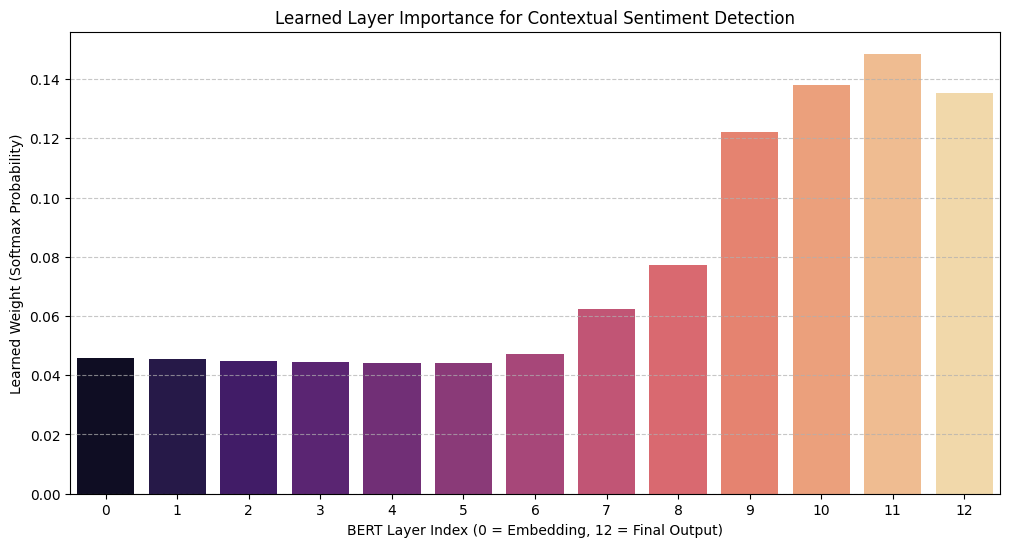

In [19]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7: Final Testing & Layer Weight Visualization
#--------------------------------------------------------------------------------------------------------

# 1. Load the "Golden" version of your model
# This ensures we are testing the best version saved during training
model.load_state_dict(torch.load('best_weighted_bert.bin'))
model.eval()

# 2. Final Test on Balanced Set
test_preds, test_labels = [], []
with torch.no_grad():
    # FIX: Changed test_loader to test_data_loader to match Module 5
    for d in tqdm(test_data_loader, desc="Testing"): 
        input_ids, mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
        
        outputs = model(input_ids, mask)
        _, preds = torch.max(outputs, dim=1)
        
        test_preds.extend(preds.cpu().tolist())
        test_labels.extend(labels.cpu().tolist())

# 3. Scientific Reporting
print("\n📝 FINAL CLASSIFICATION REPORT (Balanced Test Set)")
# Labels: 0: Normal, 1: Depression, 2: Anxiety, 3: Suicidal
target_names = ['Normal', 'Depression', 'Anxiety', 'Suicidal']
print(classification_report(test_labels, test_preds, target_names=target_names))

# 4. Weighted Layer Visualization
# This is the "MSc Evidence" showing which BERT layers the model prioritized
weights = torch.softmax(model.layer_weights, dim=0).detach().cpu().numpy()
plt.figure(figsize=(12, 6))
sns.barplot(x=list(range(13)), y=weights, palette="magma")
plt.title("Learned Layer Importance for Contextual Sentiment Detection")
plt.xlabel("BERT Layer Index (0 = Embedding, 12 = Final Output)")
plt.ylabel("Learned Weight (Softmax Probability)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()